In [71]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# def load_data(train_data_path, target_data_path, test_data_path):
#     X_train = pd.read_csv(train_data_path, index_col='id')
#     X_train.index = X_train.index.astype(int)
#     y_train = pd.read_csv(target_data_path, index_col='id')
#     y_train.index = y_train.index.astype(int)
#     X_test = pd.read_csv(test_data_path, index_col='id')
#     X_test.index = X_test.index.astype(int)
#     return X_train, y_train, X_test

# Load data
# X_train_df = pd.read_csv("data/X_train.csv", index_col='id').fillna(0)
# X_test_df = pd.read_csv("data/X_test.csv", index_col='id').fillna(0)
X_train_df = pd.read_csv("data/X_train.csv", index_col='id')
X_test_df = pd.read_csv("data/X_test.csv", index_col='id')
y_train_df = pd.read_csv("data/y_train.csv", index_col='id')


In [83]:

#create dataset and trainloader
import torch
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
import numpy as np

def symmetric_pad(seq, max_length):
    # Calculate the length of the valid data in the sequence
    valid_length = seq.notna().sum()
    print(valid_length)
    valid_length=valid_length-1
    # Create an initially empty array to hold the padded sequence
    padded_seq = np.array([])

    # Repeat the sequence symmetrically until the maximum length is reached or exceeded
    while len(padded_seq) < max_length:
        # Add the sequence and its mirror version to the padded sequence
        padded_seq = np.concatenate([seq.iloc[:valid_length].values, seq.iloc[:valid_length].values, padded_seq])

    # Trim the sequence if it exceeds the maximum length
    return pd.Series(padded_seq[:max_length])

# Load data
# X_train_df = pd.read_csv("data/X_train.csv", index_col='id')

# Pad sequences
max_length = 17807
X_train_padded = X_train_df.apply(lambda x: symmetric_pad(x, max_length), axis=1)

# # Convert to PyTorch tensors
# X_train_tensor = torch.tensor(X_train_padded.values, dtype=torch.float32)

# # Assuming y_train_df is your target data
# y_train_tensor = torch.tensor(y_train_df.values, dtype=torch.long)

print(X_train_padded.shape, X_test_df.shape, y_train_df.shape)

# Select a subset of features for simplicity
X_train_padded = X_train_padded.iloc[:, :5000]

# Convert data to NumPy arrays and reshape for LSTM
X_train = X_train_padded.to_numpy().reshape(-1, 5000, 1)  # Reshape to (samples, time_steps, features)
y_train = y_train_df.to_numpy().ravel()

# def cut_sequence_into_pieces(seq, piece_length):
#     # Cut the sequence into pieces of length 'piece_length'
#     return [seq[i:i + piece_length] for i in range(0, len(seq), piece_length)]


# # Desired piece length
# piece_length = 2000

# # Cut sequences into pieces and store them
# sequence_pieces = []
# y_labels = []

# for index, row in X_train_df.iterrows():
#     pieces = cut_sequence_into_pieces(row.dropna(), piece_length)
#     sequence_pieces.extend(pieces)
#     # Assuming y_train_df is your target data and has the same index as X_train_df
#     y_labels.extend([y_train_df.loc[index]] * len(pieces))

# # Convert to NumPy arrays and then to PyTorch tensors
# X_train_np = np.array(sequence_pieces)
# y_train_np = np.array(y_labels)
# X_train=X_train_np
# y_train=y_train_np



# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2)

# Convert to PyTorch tensors
X_train, y_train = torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long)
X_test, y_test = torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long)

# Create TensorDataset and DataLoader
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)


16322
8553
8225
8717
8462
8031
8804
8506
17281
3514
8331
8381
8299
10246
8459
8270
4071
8339
8158
3495
8198
8236
8356
12156
8406
8298
9874
8402
5899
2838
8102
8219
8001
16558
8251
8352
8324
8532
16162
8171
16122
8566
16389
8570
16569
7916
8633
3565
7987
16949
8363
8638
8131
8100
9011
8414
8346
8340
8146
8548
8440
8351
8571
8459
17271
8739
8443
8569
8588
4688
8492
5938
8319
7970
8194
8255
8760
8373
12473
10867
8328
7958
12434
8550
8376
3430
8223
8509
8132
8358
8869
8367
17124
7050
8189
8261
3474
12393
8599
7856
16184
17355
5609
4190
8610
8689
17457
8595
4024
16334
7841
8044
8321
7916
16161
8060
8177
16319
8272
8513
8377
8462
7957
9965
8007
8178
8255
8115
5642
8075
8063
16771
8476
8584
8401
8393
12074
16522
8489
8027
8003
8489
8363
15969
8574
8313
8476
8545
8039
8139
8541
8601
16681
8561
8390
2959
17656
11358
8341
8535
9518
8556
8158
8409
8541
8442
8301
8381
8278
8325
8196
7979
5397
8158
8187
8464
8151
7995
8236
8897
8239
8463
8544
8465
16317
8985
4266
8103
8362
8188
8224
8452
8185
8499


In [77]:
# X_train_tensor[:, -1000:]
# X_train.shape
X_train.isnan().any()#  (1)[:100]

tensor(False)

In [88]:
import torch.nn as nn


class ECG_LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(ECG_LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # Initialize hidden state and cell state
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))

        # Decode the hidden state of the last time step
        out = self.fc(out[:, -1, :])
        return out
    
# Model parameters
input_size = 1  # Number of features
hidden_size = 128  # Number of features in hidden state
num_layers = 2  # Number of stacked LSTM layers
num_classes = 4  # Number of output classes

model = ECG_LSTM(input_size, hidden_size, num_layers, num_classes)
device = "cuda:0" if torch.cuda.is_available() else "cpu"
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

In [89]:

# Function to evaluate the model (you might need to modify this based on your specific requirements)
def evaluate_model(model, data_loader):
    model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in data_loader:
            inputs, labels = batch[0].to(device), batch[1].to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            # print(f"Batch Processed: Correct - {correct}, Total - {total}")  # Debugging line

    accuracy = 100 * correct / total if total > 0 else None
    # print(f"Accuracy Calculated: {accuracy}")  # Debugging line
    return accuracy


# Training loop
num_epochs = 100
for epoch in range(num_epochs):
    for i, (inputs, labels) in enumerate(train_loader):
        model.train() 
        inputs, labels = inputs.to(device), labels.to(device)

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Print loss
        if (i + 1) % 50 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')
            
            
    if (epoch + 1) % 10 == 0:
        print(f"Testing after Epoch {epoch + 1}")
        test_accuracy = evaluate_model(model, test_loader)  # Assuming 'evaluate_model' is defined for accuracy calculation
        print(f"Test Accuracy after Epoch {epoch + 1}: {test_accuracy:.2f}%")

        # Optionally save the model at this point
        ckpt_path = f'ckpts/ecg_lstm_model_epoch_{epoch + 1}.pth'
        torch.save(model.state_dict(), ckpt_path)

            
# ckpt_path = 'ckpts/ecg_lstm_model_weights.pth'
# torch.save(model.state_dict(), ckpt_path)

Epoch [1/100], Step [50/256], Loss: 1.0832
Epoch [1/100], Step [100/256], Loss: 0.8625
Epoch [1/100], Step [150/256], Loss: 1.0429
Epoch [1/100], Step [200/256], Loss: 1.2790
Epoch [1/100], Step [250/256], Loss: 0.9862
Epoch [2/100], Step [50/256], Loss: 1.0382
Epoch [2/100], Step [100/256], Loss: 0.9068
Epoch [2/100], Step [150/256], Loss: 1.3546
Epoch [2/100], Step [200/256], Loss: 1.1712
Epoch [2/100], Step [250/256], Loss: 1.2096
Epoch [3/100], Step [50/256], Loss: 0.9237
Epoch [3/100], Step [100/256], Loss: 0.9420
Epoch [3/100], Step [150/256], Loss: 0.8757
Epoch [3/100], Step [200/256], Loss: 1.4011
Epoch [3/100], Step [250/256], Loss: 1.2392
Epoch [4/100], Step [50/256], Loss: 1.0167
Epoch [4/100], Step [100/256], Loss: 1.3188
Epoch [4/100], Step [150/256], Loss: 0.7017
Epoch [4/100], Step [200/256], Loss: 1.2830
Epoch [4/100], Step [250/256], Loss: 0.9233


In [ ]:
import pandas as pd
import torch


#create dataset and trainloader
import torch
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
import numpy as np

def symmetric_pad(seq, max_length):
    # Calculate the length of the valid data in the sequence
    valid_length = seq.notna().sum()
    print(valid_length)
    valid_length=valid_length-1
    # Create an initially empty array to hold the padded sequence
    padded_seq = np.array([])

    # Repeat the sequence symmetrically until the maximum length is reached or exceeded
    while len(padded_seq) < max_length:
        # Add the sequence and its mirror version to the padded sequence
        padded_seq = np.concatenate([seq.iloc[:valid_length].values, seq.iloc[:valid_length].values, padded_seq])

    # Trim the sequence if it exceeds the maximum length
    return pd.Series(padded_seq[:max_length])



# model = ECG_LSTM(input_size, hidden_size, num_layers, num_classes)  # Initialize it with the same parameters
# model.load_state_dict(torch.load(ckpt_path))
model.eval()




# Assuming your model and other necessary components are already defined and loaded

# Load the test data
X_test_df = pd.read_csv("data/X_test.csv", index_col='id').fillna(0)


# Load data
# X_train_df = pd.read_csv("data/X_train.csv", index_col='id')

# Pad sequences
max_length = 17807
X_test_padded = X_test_df.apply(lambda x: symmetric_pad(x, max_length), axis=1)

# Preprocess the test data (Make sure this is consistent with how you processed training data)
X_test = X_test_padded.iloc[:, :5000].to_numpy().reshape(-1, 5000, 1)  # Reshape as needed for your model
X_test = torch.tensor(X_test, dtype=torch.float32)
# Create a DataLoader for the test data
test_dataset = TensorDataset(X_test)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)  # Adjust batch_size as needed

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Function to evaluate the model in batches
def evaluate_model(model, data_loader):
    model.eval()  # Set the model to evaluation mode
    total_predictions = []
    with torch.no_grad():
        for batch in data_loader:
            inputs = batch[0].to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total_predictions.extend(predicted.cpu().numpy())
    return total_predictions

# Evaluate the model
predicted_labels = evaluate_model(model, test_loader)

# Create a DataFrame for submission
submission_df = pd.DataFrame({
    'id': X_test_df.index,
    'y': predicted_labels
})

# Save to a file
submission_df.to_csv("data/sample_submission.csv", index=False)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Example: Random model predictions and ground truth labels
predictions = torch.randn(64, 10)  # 64 samples, 10 classes
labels = torch.randint(0, 10, (64,))  # Random labels between 0 and 9

# Define CrossEntropyLoss
criterion = nn.CrossEntropyLoss()

# Calculate the loss
loss = criterion(predictions, labels)

In [ ]:
import numpy as np
import torch

# Create a NumPy array
numpy_array = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

# Convert NumPy array to PyTorch tensor using torch.from_numpy()
tensor_from_numpy = torch.from_numpy(numpy_array)

# Convert NumPy array to PyTorch tensor using torch.Tensor()
tensor_from_tensor = torch.Tensor(numpy_array)

print("NumPy Array:")
print(numpy_array)

print("\nPyTorch Tensor (from torch.from_numpy()):")
print(tensor_from_numpy)

print("\nPyTorch Tensor (from torch.Tensor()):")
print(tensor_from_tensor)




NumPy Array:
[[1 2 3]
 [4 5 6]
 [7 8 9]]

PyTorch Tensor (from torch.from_numpy()):
tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])

PyTorch Tensor (from torch.Tensor()):
tensor([[1., 2., 3.],
        [4., 5., 6.],
        [7., 8., 9.]])


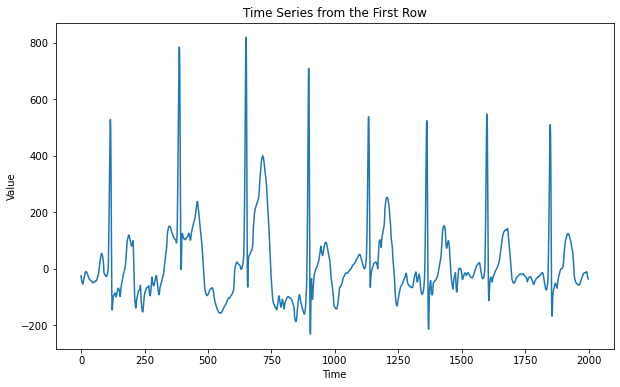

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(2000), X_train_df.iloc[500, 0:2000], linestyle='-')
plt.title('Time Series from the First Row')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()